[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Data-Crew/transport-networks-lab/blob/main/Notebooks/Ejercitacion_IntroNx.ipynb)

# Ejercitación — Grafos con `NetworkX`

Cuatro ejercicios sobre el mismo recorte de la red de subtes de la práctica
guiada. Corré primero la celda de setup: reconstruye el grafo `G` tal como
quedó al final del notebook anterior.

Mounted at /drive/


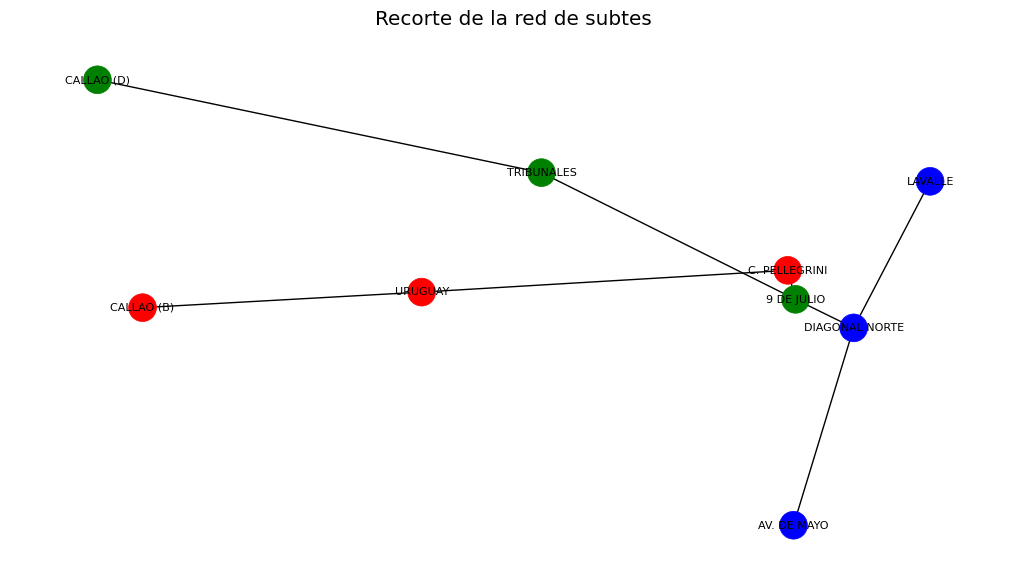

In [1]:
#@title Setup: reconstruye el grafo de la práctica guiada
import random

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

random.seed(42)
plt.style.use("ggplot")

# (nodo, nombre en el CSV, línea, etiqueta para el gráfico)
ESTACIONES = [
    (0, "CALLAO - MAESTRO ALFREDO BRAVO", "B", "CALLAO (B)"),
    (1, "URUGUAY", "B", "URUGUAY"),
    (2, "C. PELLEGRINI", "B", "C. PELLEGRINI"),
    (3, "CALLAO", "D", "CALLAO (D)"),
    (4, "TRIBUNALES - TEATRO COLÓN", "D", "TRIBUNALES"),
    (5, "9 DE JULIO", "D", "9 DE JULIO"),
    (6, "LAVALLE", "C", "LAVALLE"),
    (7, "DIAGONAL NORTE", "C", "DIAGONAL NORTE"),
    (8, "AV. DE MAYO", "C", "AV. DE MAYO"),
]
COLOR_LINEA = {"B": "red", "C": "blue", "D": "green"}
COMBINACIONES = [(2, 5), (5, 7)]


def crear_grafo(data_dir="/drive/MyDrive/transport-networks-lab/Data"):
    """Devuelve el grafo de subtes con atributos de nodos y ejes."""
    G = nx.Graph()
    G.add_nodes_from(range(9))
    for n in range(0, 9, 3):
        G.add_edge(n, n + 1)
        G.add_edge(n + 1, n + 2)
    for u, v in COMBINACIONES:
        G.add_edge(u, v)

    subte = pd.read_csv(f"{data_dir}/estaciones-de-subte.csv")
    coords = {(r.estacion, r.linea): (r.long, r.lat) for r in subte.itertuples()}

    for nodo, estacion, linea, etiqueta in ESTACIONES:
        G.nodes[nodo]["estacion"] = etiqueta
        G.nodes[nodo]["nombre_csv"] = estacion
        G.nodes[nodo]["linea"] = linea
        G.nodes[nodo]["color"] = COLOR_LINEA[linea]
        G.nodes[nodo]["coord"] = coords[(estacion, linea)]

    for u, v in G.edges():
        es_comb = (u, v) in COMBINACIONES or (v, u) in COMBINACIONES
        G.edges[u, v]["pasajeros"] = (
            random.randint(100, 200) if es_comb else random.randint(10, 100)
        )
    return G


def dibujar(G, ax=None, titulo="", node_size=400, node_color=None):
    """Dibuja el grafo usando las coordenadas guardadas en los nodos."""
    if ax is None:
        _, ax = plt.subplots(figsize=(13, 7))
    pos = nx.get_node_attributes(G, "coord")
    etiquetas = nx.get_node_attributes(G, "estacion")
    if node_color is None:
        node_color = [G.nodes[n]["color"] for n in G.nodes()]

    nx.draw(G, pos, labels=etiquetas, with_labels=True, font_size=8,
            node_size=node_size, node_color=node_color,
            arrows=G.is_directed(),
            connectionstyle="arc3, rad=0.1" if G.is_directed() else "arc3",
            ax=ax)
    ax.set_title(titulo)
    return ax


from google.colab import drive
drive.mount("/drive/")

G = crear_grafo()
dibujar(G, titulo="Recorte de la red de subtes")
plt.show()

## Ejercicio 1 — Elegir la clase de grafo

Nuestro `G` es un `Graph`. Queremos responder esta pregunta:

> *¿Cuántos pasajeros viajan de `C. PELLEGRINI` hacia `9 DE JULIO`, y cuántos
> en el sentido inverso?*

**a.** ¿Puede `G` responderla? Probá con `G.edges[2, 5]` y `G.edges[5, 2]`.

**b.** Convertí `G` en dirigido con `to_directed()` y repartí los pasajeros de
cada eje entre los dos sentidos (mitad y mitad, sin perder ninguno).

**c.** Verificá que la suma de ambos sentidos sea igual al total original.

In [ ]:
# Desarrollar ejercicio

G.edges[2, 5] -> {'pasajeros': 103}
G.edges[5, 2] -> {'pasajeros': 103}
¿Son el mismo objeto? True

Pellegrini → 9 de Julio: 52
9 de Julio → Pellegrini: 51

OK: se conserva el total en todos los ejes


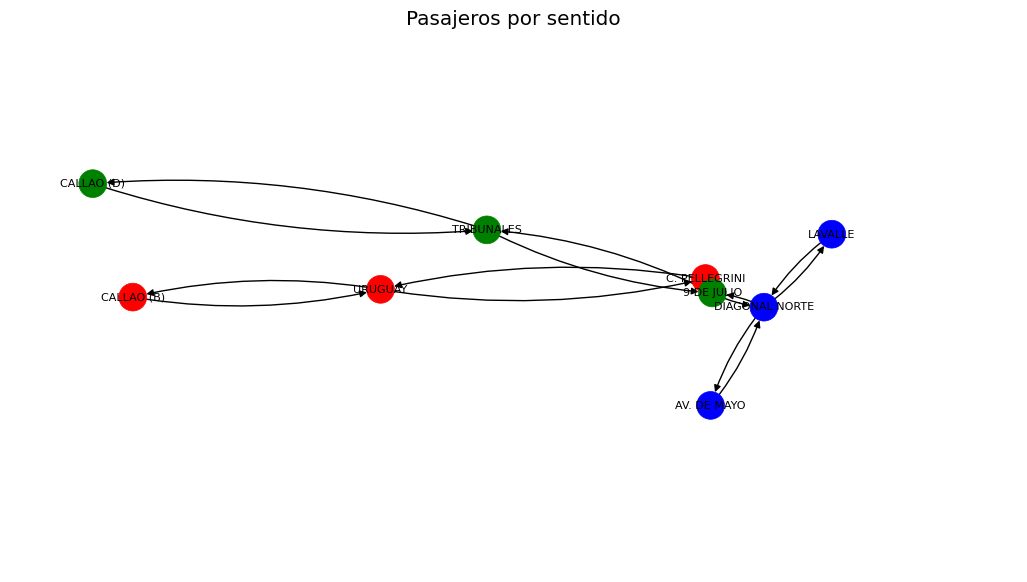

In [2]:
#@title Solución
# a. Un Graph no distingue sentido: las dos consultas devuelven lo mismo
print("G.edges[2, 5] ->", G.edges[2, 5])
print("G.edges[5, 2] ->", G.edges[5, 2])
print("¿Son el mismo objeto?", G.edges[2, 5] is G.edges[5, 2])

# b. En un DiGraph cada sentido es un eje propio.
# to_directed() copia el atributo en ambos, así que hay que repartirlo:
# la división entera va a los dos, y el resto (0 o 1) se lo lleva un sentido.
GD = G.to_directed()

for u, v in G.edges():
    total = G.edges[u, v]["pasajeros"]
    GD.edges[u, v]["pasajeros"] = total // 2 + total % 2
    GD.edges[v, u]["pasajeros"] = total // 2

print("\nPellegrini → 9 de Julio:", GD.edges[2, 5]["pasajeros"])
print("9 de Julio → Pellegrini:", GD.edges[5, 2]["pasajeros"])

# c. Ningún pasajero se perdió en el camino
assert all(
    GD.edges[u, v]["pasajeros"] + GD.edges[v, u]["pasajeros"] == G.edges[u, v]["pasajeros"]
    for u, v in G.edges()
)
print("\nOK: se conserva el total en todos los ejes")

dibujar(GD, titulo="Pasajeros por sentido")
plt.show()

In [3]:
#@title 📌 Ver conclusión del ejercicio 1
from IPython.display import Markdown, display

display(Markdown("""
**Lo que muestra este ejercicio**

La pregunta no se podía responder, y el problema no era de código: era del
**modelo**. `G.edges[2, 5]` y `G.edges[5, 2]` no devuelven valores parecidos,
devuelven *el mismo diccionario* — en un `Graph` el par de nodos no está
ordenado, así que la pregunta "¿en qué sentido?" no tiene dónde alojarse.

Cambiar de clase es lo que crea el lugar donde guardar esa información. Por eso
la clase de grafo se elige **antes** de cargar los datos, en función de las
preguntas que se quieran responder después.

**Sobre el reparto:** con un número impar de pasajeros no se puede partir por la
mitad exacta. Usamos `total // 2 + total % 2` para un sentido y `total // 2`
para el otro: el resto se lo lleva siempre el mismo, y así la suma cierra. Es
una decisión arbitraria pero explícita — repartir al azar también sirve, pero
haría que el resultado cambie en cada corrida sin ningún motivo.
"""))


**Lo que muestra este ejercicio**

La pregunta no se podía responder, y el problema no era de código: era del
**modelo**. `G.edges[2, 5]` y `G.edges[5, 2]` no devuelven valores parecidos,
devuelven *el mismo diccionario* — en un `Graph` el par de nodos no está
ordenado, así que la pregunta "¿en qué sentido?" no tiene dónde alojarse.

Cambiar de clase es lo que crea el lugar donde guardar esa información. Por eso
la clase de grafo se elige **antes** de cargar los datos, en función de las
preguntas que se quieran responder después.

**Sobre el reparto:** con un número impar de pasajeros no se puede partir por la
mitad exacta. Usamos `total // 2 + total % 2` para un sentido y `total // 2`
para el otro: el resto se lo lleva siempre el mismo, y así la suma cierra. Es
una decisión arbitraria pero explícita — repartir al azar también sirve, pero
haría que el resultado cambie en cada corrida sin ningún motivo.


## Ejercicio 2 — Un ranking de estaciones

Armá una función `ranking(G, metrica, top)` que devuelva las `top` estaciones
más importantes de la red según la métrica pedida (`"grado"`,
`"centralidad"` o `"intermediacion"`), con el **nombre** de la estación y no
el número de nodo.

Usala para comparar el top 3 de cada métrica. ¿Dan el mismo resultado?

In [ ]:
# Desarrollar ejercicio

In [4]:
#@title Solución
METRICAS = {
    "grado": lambda G: dict(G.degree()),
    "centralidad": nx.degree_centrality,
    "intermediacion": nx.betweenness_centrality,
}


def ranking(G, metrica, top=3):
    """Devuelve las `top` estaciones según la métrica indicada.

    Args:
        G: grafo con atributo 'estacion' en cada nodo.
        metrica: una clave de METRICAS.
        top: cuántas estaciones devolver.

    Returns:
        Serie indexada por nombre de estación, ordenada de mayor a menor.
    """
    if metrica not in METRICAS:
        raise ValueError(f"Métrica desconocida: {metrica}. Opciones: {list(METRICAS)}")

    valores = METRICAS[metrica](G)
    return (
        pd.Series({G.nodes[n]["estacion"]: v for n, v in valores.items()})
        .sort_values(ascending=False)
        .head(top)
        .round(3)
    )


for m in METRICAS:
    print(f"--- {m} ---")
    print(ranking(G, m).to_string(), "\n")

--- grado ---
DIAGONAL NORTE    3
9 DE JULIO        3
TRIBUNALES        2 

--- centralidad ---
DIAGONAL NORTE    0.375
9 DE JULIO        0.375
TRIBUNALES        0.250 

--- intermediacion ---
9 DE JULIO        0.750
DIAGONAL NORTE    0.464
C. PELLEGRINI     0.429 



In [5]:
#@title 📌 Ver conclusión del ejercicio 2
from IPython.display import Markdown, display

display(Markdown("""
**Grado y centralidad de grado dan el mismo ranking**

No es casualidad: la centralidad de grado *es* el grado dividido por `N − 1`,
que es una constante para todo el grafo. Dividir todos los valores por el mismo
número no cambia el orden. Sirve para **comparar entre redes** de distinto
tamaño, no para reordenar dentro de una.

**La intermediación sí reordena**

`9 DE JULIO` y `DIAGONAL NORTE` tienen el mismo grado (3), pero muy distinta
intermediación (0,75 contra 0,46). Y `C. PELLEGRINI`, con grado 2, tiene más
intermediación que estaciones de grado 3.

La diferencia es qué mide cada una: el grado cuenta vecinos —una propiedad
**local**—, mientras que la intermediación mide cuántos caminos de toda la red
dependen de ese nodo —una propiedad **estructural**. Una estación chica puede
ser crítica si es el único paso entre dos zonas.

**Sobre la implementación:** conviene apoyarse en las funciones de NetworkX en
vez de reimplementar las fórmulas. El diccionario `METRICAS` permite agregar
una métrica nueva en una línea, sin tocar `ranking`.
"""))


**Grado y centralidad de grado dan el mismo ranking**

No es casualidad: la centralidad de grado *es* el grado dividido por `N − 1`,
que es una constante para todo el grafo. Dividir todos los valores por el mismo
número no cambia el orden. Sirve para **comparar entre redes** de distinto
tamaño, no para reordenar dentro de una.

**La intermediación sí reordena**

`9 DE JULIO` y `DIAGONAL NORTE` tienen el mismo grado (3), pero muy distinta
intermediación (0,75 contra 0,46). Y `C. PELLEGRINI`, con grado 2, tiene más
intermediación que estaciones de grado 3.

La diferencia es qué mide cada una: el grado cuenta vecinos —una propiedad
**local**—, mientras que la intermediación mide cuántos caminos de toda la red
dependen de ese nodo —una propiedad **estructural**. Una estación chica puede
ser crítica si es el único paso entre dos zonas.

**Sobre la implementación:** conviene apoyarse en las funciones de NetworkX en
vez de reimplementar las fórmulas. El diccionario `METRICAS` permite agregar
una métrica nueva en una línea, sin tocar `ranking`.


## Ejercicio 3 — El viaje más largo

**a.** Encontrá el par de estaciones **más lejano** de la red: el que necesita
más tramos para conectarse. Mostralo con nombres y con el recorrido completo.

**b.** ¿Cuántos tramos son? Ese número tiene un nombre en teoría de grafos:
buscá qué calcula `nx.diameter`.

*Pista: `nx.all_pairs_shortest_path_length(G)` devuelve todos los largos.*

In [ ]:
# Desarrollar ejercicio

In [6]:
#@title Solución
largos = dict(nx.all_pairs_shortest_path_length(G))

# a. Buscamos el par con mayor distancia
origen, destino, mayor = max(
    ((u, v, d) for u, vecinos in largos.items() for v, d in vecinos.items()),
    key=lambda x: x[2],
)

ruta = nx.shortest_path(G, origen, destino)
print(f"Par más lejano: {G.nodes[origen]['estacion']} ({G.nodes[origen]['linea']}) "
      f"→ {G.nodes[destino]['estacion']} ({G.nodes[destino]['linea']})")
print(f"Distancia: {mayor} tramos\n")
print(" → ".join(G.nodes[n]["estacion"] for n in ruta))

# b. Esa distancia máxima es el diámetro de la red
print(f"\nnx.diameter(G) = {nx.diameter(G)}")

Par más lejano: CALLAO (B) (B) → CALLAO (D) (D)
Distancia: 5 tramos

CALLAO (B) → URUGUAY → C. PELLEGRINI → 9 DE JULIO → TRIBUNALES → CALLAO (D)

nx.diameter(G) = 5


In [7]:
#@title 📌 Ver conclusión del ejercicio 3
from IPython.display import Markdown, display

display(Markdown("""
**El diámetro es el peor caso de la red**

El **diámetro** es la mayor de todas las distancias mínimas: el viaje más largo
que alguien puede verse obligado a hacer, suponiendo que siempre elija la mejor
ruta. Es una métrica de red completa, no de un nodo.

En nuestro recorte es 5, y el par más lejano son las **dos cabeceras de las
líneas B y D** — que en la superficie están a pocas cuadras. El grafo captura
algo que el mapa esconde: la cercanía física no implica cercanía en la red.

**Por qué importa**

Un diámetro alto indica una red donde algunos viajes son desproporcionadamente
largos. Agregar una combinación entre líneas lo reduce de golpe, y es
exactamente el tipo de intervención que se evalúa al planificar una extensión.

**Un límite:** este diámetro cuenta *tramos*, tratando a todos como iguales. Un
diámetro medido en tiempo de viaje (con `weight`) daría otro resultado, porque
combinar de línea es mucho más lento que pasar una estación.
"""))


**El diámetro es el peor caso de la red**

El **diámetro** es la mayor de todas las distancias mínimas: el viaje más largo
que alguien puede verse obligado a hacer, suponiendo que siempre elija la mejor
ruta. Es una métrica de red completa, no de un nodo.

En nuestro recorte es 5, y el par más lejano son las **dos cabeceras de las
líneas B y D** — que en la superficie están a pocas cuadras. El grafo captura
algo que el mapa esconde: la cercanía física no implica cercanía en la red.

**Por qué importa**

Un diámetro alto indica una red donde algunos viajes son desproporcionadamente
largos. Agregar una combinación entre líneas lo reduce de golpe, y es
exactamente el tipo de intervención que se evalúa al planificar una extensión.

**Un límite:** este diámetro cuenta *tramos*, tratando a todos como iguales. Un
diámetro medido en tiempo de viaje (con `weight`) daría otro resultado, porque
combinar de línea es mucho más lento que pasar una estación.


## Ejercicio 4 — ¿Qué pasa si cierra una estación?

En la práctica guiada vimos que `9 DE JULIO` tiene la intermediación más alta.
Comprobemos qué significa eso en la práctica.

**a.** Escribí una función que elimine una estación del grafo (sobre una copia,
sin tocar `G`) e informe si la red sigue conexa y en cuántos pedazos quedó.

**b.** Aplicala a tres estaciones con intermediación muy distinta:
`9 DE JULIO` (0,75), `URUGUAY` (0,25) y `AV. DE MAYO` (0,00).

**c.** ¿La intermediación predice bien el daño? Mirá no sólo *si* se parte,
sino en **cuántos pedazos** y de qué tamaño.

In [ ]:
# Desarrollar ejercicio

In [8]:
#@title Solución
def simular_cierre(G, estacion):
    """Elimina una estación (por su etiqueta) y reporta el impacto."""
    nodo = next(n for n, d in G.nodes(data=True)
                if d["estacion"] == estacion)

    H = G.copy()
    H.remove_node(nodo)
    componentes = sorted(nx.connected_components(H), key=len, reverse=True)

    bc = nx.betweenness_centrality(G)[nodo]
    print(f"Cierra {estacion} — betweenness {bc:.2f}")
    print(f"  ¿Sigue conexa? {nx.is_connected(H)} | pedazos: {len(componentes)}")
    for i, comp in enumerate(componentes, 1):
        nombres = sorted(H.nodes[n]["estacion"] for n in comp)
        print(f"    {i} ({len(nombres)} estaciones): {', '.join(nombres)}")
    print()
    return H


sin_9j = simular_cierre(G, "9 DE JULIO")      # betweenness 0.75
sin_uru = simular_cierre(G, "URUGUAY")        # betweenness 0.25
sin_mayo = simular_cierre(G, "AV. DE MAYO")   # betweenness 0.00

Cierra 9 DE JULIO — betweenness 0.75
  ¿Sigue conexa? False | pedazos: 3
    1 (3 estaciones): C. PELLEGRINI, CALLAO (B), URUGUAY
    2 (3 estaciones): AV. DE MAYO, DIAGONAL NORTE, LAVALLE
    3 (2 estaciones): CALLAO (D), TRIBUNALES

Cierra URUGUAY — betweenness 0.25
  ¿Sigue conexa? False | pedazos: 2
    1 (7 estaciones): 9 DE JULIO, AV. DE MAYO, C. PELLEGRINI, CALLAO (D), DIAGONAL NORTE, LAVALLE, TRIBUNALES
    2 (1 estaciones): CALLAO (B)

Cierra AV. DE MAYO — betweenness 0.00
  ¿Sigue conexa? True | pedazos: 1
    1 (8 estaciones): 9 DE JULIO, C. PELLEGRINI, CALLAO (B), CALLAO (D), DIAGONAL NORTE, LAVALLE, TRIBUNALES, URUGUAY



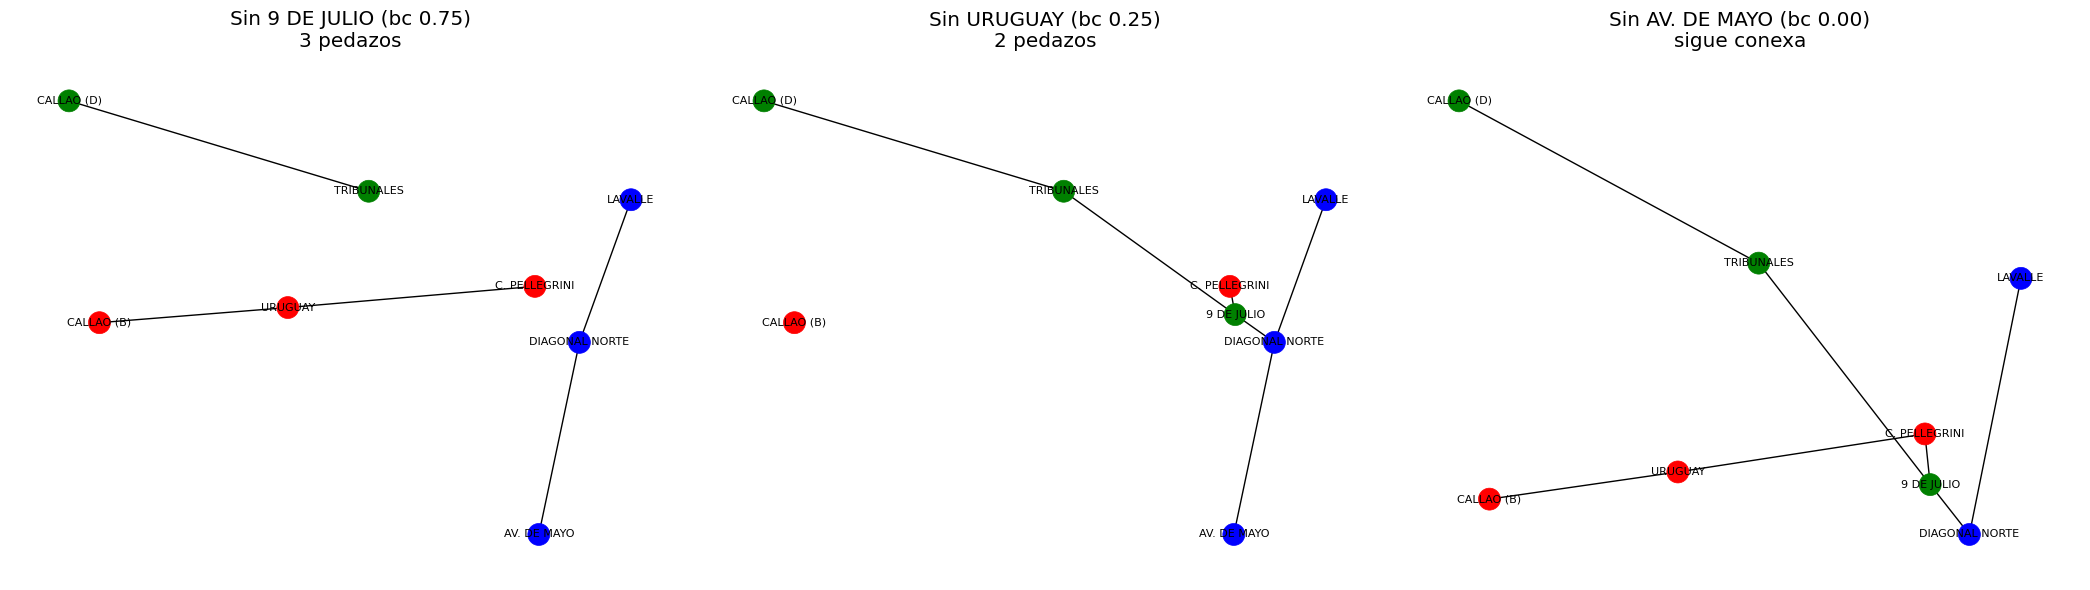

In [9]:
#@title Solución (visualización)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, g, t in zip(axes,
                    [sin_9j, sin_uru, sin_mayo],
                    ["Sin 9 DE JULIO (bc 0.75)\n3 pedazos",
                     "Sin URUGUAY (bc 0.25)\n2 pedazos",
                     "Sin AV. DE MAYO (bc 0.00)\nsigue conexa"]):
    dibujar(g, ax=ax, titulo=t, node_size=250)
plt.tight_layout()
plt.show()

In [10]:
#@title 📌 Ver conclusión del ejercicio 4
from IPython.display import Markdown, display

display(Markdown("""
**La intermediación predice la gravedad, no sólo el hecho**

Los tres cierres dan resultados distintos, y siguen el orden de la betweenness:

| Estación | Betweenness | Resultado |
|---|---|---|
| `9 DE JULIO` | 0,75 | 3 pedazos de 3, 3 y 2 estaciones |
| `URUGUAY` | 0,25 | 2 pedazos: 7 estaciones y 1 aislada |
| `AV. DE MAYO` | 0,00 | sigue conexa |

Ojo con la lectura fácil: **`URUGUAY` también parte la red**. Lo que cambia no
es *si* se rompe, sino *cuánto*. Sacar `URUGUAY` aísla una sola estación
terminal; sacar `9 DE JULIO` deja tres fragmentos incomunicados de tamaño
parecido, que es el peor escenario posible.

**Por qué casi cualquier cierre rompe esta red**

Porque el grafo es un **árbol**: no tiene ciclos, así que entre cada par de
estaciones hay un único camino y no existen rutas alternativas. En un árbol,
*todo* nodo que no sea una punta es un punto de articulación. Podés verificarlo
con `list(nx.articulation_points(G))`: da los cinco nodos internos.

Las únicas estaciones inofensivas son las **terminales** (grado 1), que no están
en el camino de nadie — y por eso su betweenness es exactamente 0.

**Qué significa fuera del ejercicio**

La red de subtes real no es un árbol: tiene combinaciones múltiples y por lo
tanto ciclos, y esa redundancia es lo que la hace resiliente. Este recorte
muestra el caso extremo de una red sin alternativas.

**Para pensar:** ¿alcanza con agregar *un* eje para que la caída de
`9 DE JULIO` deje de partir la red? Probá primero con `H.add_edge(2, 7)`
—conectar Pellegrini con Diagonal Norte— y chequeá `nx.is_connected`.

La respuesta es que no alcanza, y el motivo vale la pena razonarlo: al sacar
`9 DE JULIO` quedan **tres** fragmentos, y un eje nuevo puede unir a lo sumo
dos. Hacen falta como mínimo dos ejes. Probá `H.add_edge(2, 7)` junto con
`H.add_edge(2, 4)` y volvé a chequear.
"""))


**La intermediación predice la gravedad, no sólo el hecho**

Los tres cierres dan resultados distintos, y siguen el orden de la betweenness:

| Estación | Betweenness | Resultado |
|---|---|---|
| `9 DE JULIO` | 0,75 | 3 pedazos de 3, 3 y 2 estaciones |
| `URUGUAY` | 0,25 | 2 pedazos: 7 estaciones y 1 aislada |
| `AV. DE MAYO` | 0,00 | sigue conexa |

Ojo con la lectura fácil: **`URUGUAY` también parte la red**. Lo que cambia no
es *si* se rompe, sino *cuánto*. Sacar `URUGUAY` aísla una sola estación
terminal; sacar `9 DE JULIO` deja tres fragmentos incomunicados de tamaño
parecido, que es el peor escenario posible.

**Por qué casi cualquier cierre rompe esta red**

Porque el grafo es un **árbol**: no tiene ciclos, así que entre cada par de
estaciones hay un único camino y no existen rutas alternativas. En un árbol,
*todo* nodo que no sea una punta es un punto de articulación. Podés verificarlo
con `list(nx.articulation_points(G))`: da los cinco nodos internos.

Las únicas estaciones inofensivas son las **terminales** (grado 1), que no están
en el camino de nadie — y por eso su betweenness es exactamente 0.

**Qué significa fuera del ejercicio**

La red de subtes real no es un árbol: tiene combinaciones múltiples y por lo
tanto ciclos, y esa redundancia es lo que la hace resiliente. Este recorte
muestra el caso extremo de una red sin alternativas.

**Para pensar:** ¿alcanza con agregar *un* eje para que la caída de
`9 DE JULIO` deje de partir la red? Probá primero con `H.add_edge(2, 7)`
—conectar Pellegrini con Diagonal Norte— y chequeá `nx.is_connected`.

La respuesta es que no alcanza, y el motivo vale la pena razonarlo: al sacar
`9 DE JULIO` quedan **tres** fragmentos, y un eje nuevo puede unir a lo sumo
dos. Hacen falta como mínimo dos ejes. Probá `H.add_edge(2, 7)` junto con
`H.add_edge(2, 4)` y volvé a chequear.
